# AIoT Project — Exploratory Notebook

Αυτό το notebook χρησιμοποιήθηκε κυρίως για **εξερεύνηση και πειραματισμό**. Δοκιμάσαμε διαφορετικές προσεγγίσεις split, preprocessing και ταξινόμησης για να πάρουμε μια γενική εικόνα πριν προχωρήσουμε στα κύρια notebooks της υλοποίησης. Ο κώδικας εδώ  είναι ξεκάθαρα για να πάρουμε μια εικόνα για το πως είναι τα δεδομένα(κάναμε plots),τι καθαρισμό πρέπει να κάνουμε κλπ κλπ— περιέχει δοκιμές που μερικές φορές οδήγησαν σε λανθασμένα συμπεράσματα (π.χ. user-based split), τα οποία στη συνέχεια διορθώσαμε.

In [ ]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

Start time of execution

In [ ]:
time_start = time()

## Load configuration

Φορτώνουμε το `config.yml` με τις παραμέτρους και συνδεόμαστε στη MongoDB.

In [1]:
import yaml
import os

config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [2]:
import pymongo

client = pymongo.MongoClient(config["client"])

In [3]:
db = client[config["db"]]
coll = db[config["col"]]

## Load data

Τραβάμε ένα δείγμα εγγραφής από τη βάση για να δούμε πώς μοιάζουν τα δεδομένα μας(δοκιμάζαμε και διαφορετικό κάθε φορά).

In [4]:
import pandas as pd

sample_doc = coll.find_one({"gesture_id": "scroll-down-index"})

if sample_doc:
    print(sample_doc)
else:
    print("No document found with that ID.")

{'_id': ObjectId('6a0df981aba82e032b2652d7'), 'data': {'acc_x': [0.512, 0.49, 0.415, 0.359, 0.423, 0.513, 0.423, 0.376, 0.42, 0.539, 0.717, 0.834, 0.763, 0.642, 0.6, 0.639, 0.679, 0.677, 0.69, 0.744, 0.743, 0.636, 0.602, 0.685, 0.662, 0.572, 0.479, 0.484, 0.624, 0.688, 0.682, 0.611, 0.552, 0.574, 0.601, 0.546, 0.512, 0.519, 0.438, 0.38, 0.491, 0.697, 0.747, 0.6, 0.496, 0.591, 0.717, 0.726, 0.705, 0.732, 0.728, 0.638, 0.632, 0.703, 0.728, 0.678, 0.613, 0.627, 0.649, 0.662, 0.705, 0.729, 0.72, 0.658, 0.565, 0.453, 0.42, 0.553, 0.681, 0.622, 0.479, 0.475, 0.671, 0.804, 0.667, 0.43, 0.363, 0.496, 0.735, 0.886, 0.789, 0.612, 0.57, 0.605, 0.626, 0.635, 0.574, 0.369, 0.296, 0.349, 0.402, 0.472, 0.571, 0.66, 0.727, 0.773, 0.823, 0.827, 0.76, 0.715, 0.695, 0.696, 0.721, 0.663, 0.487, 0.394, 0.509, 0.722, 0.794, 0.716, 0.636, 0.628, 0.631, 0.624, 0.621, 0.626, 0.646, 0.646, 0.609, 0.607, 0.675, 0.709, 0.664, 0.613, 0.592, 0.596, 0.597, 0.596, 0.611, 0.618, 0.611, 0.623, 0.639, 0.644, 0.64, 0.649

## Explore the nature of the data

Βλέπουμε το σήμα στο πεδίο χρόνου και σε 3D για να πάρουμε μια πρώτη εικόνα της κίνησης — τόσο για τον επιταχυνσιόμετρο όσο και για το γυροσκόπιο.

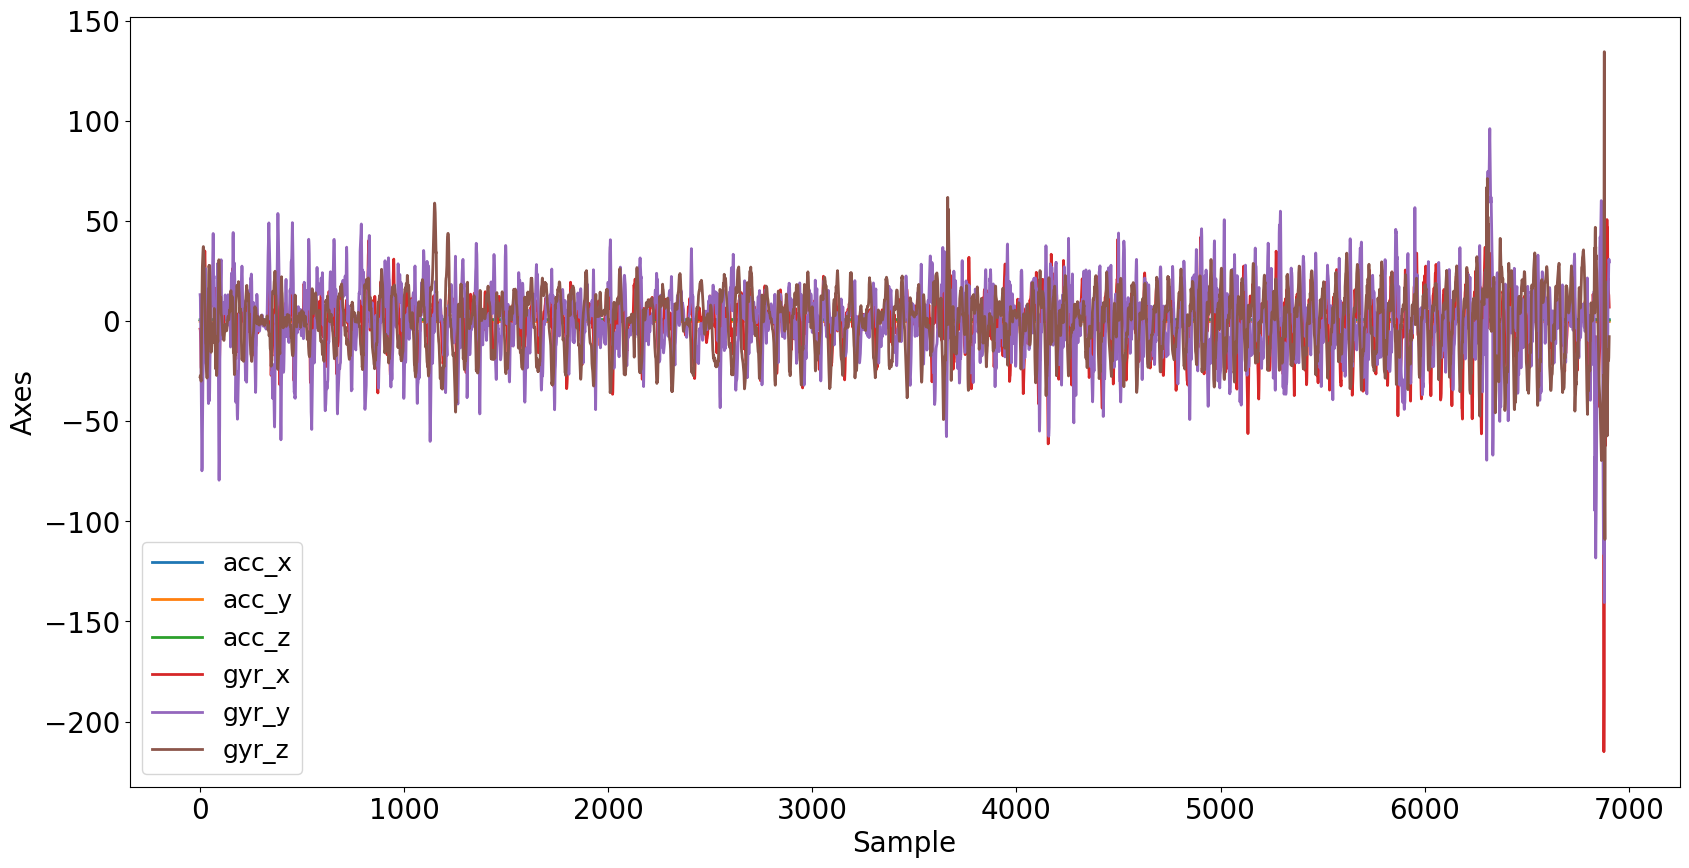

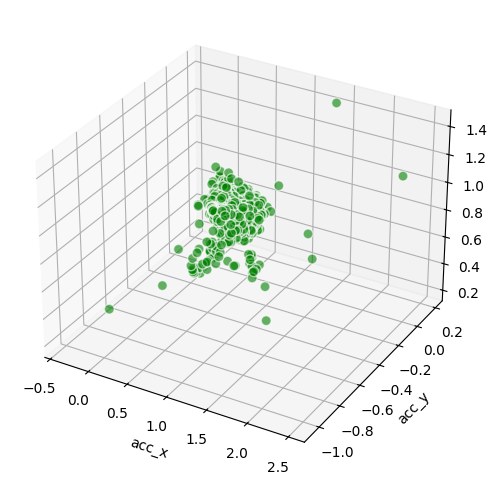

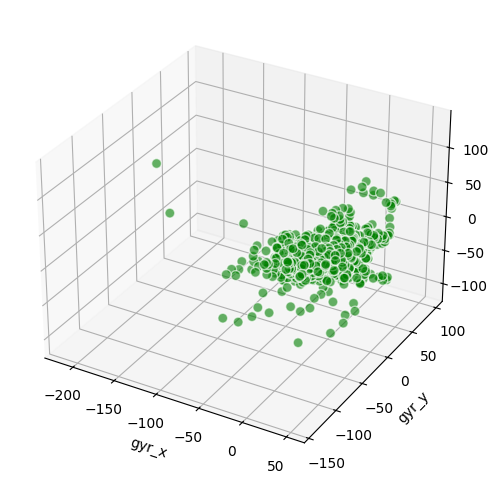

In [5]:
from utils_visual import plot_instance_time_domain, plot_instance_3d

if sample_doc:
    df = pd.DataFrame(sample_doc['data'])
    
    plot_instance_time_domain(df)
    
    acc_df = df[["acc_x", "acc_y", "acc_z"]]
    plot_instance_3d(acc_df)
    
    gyr_df = df[["gyr_x", "gyr_y", "gyr_z"]]
    plot_instance_3d(gyr_df, axes_list=("gyr_x", "gyr_y", "gyr_z"))

## Data Processing

Ορίζουμε τη συνάρτηση καθαρισμού δεδομένων: αφαιρούμε τα τελευταία δείγματα (trim), εντοπίζουμε outliers με Z-score και τα αντικαθιστούμε με linear interpolation.

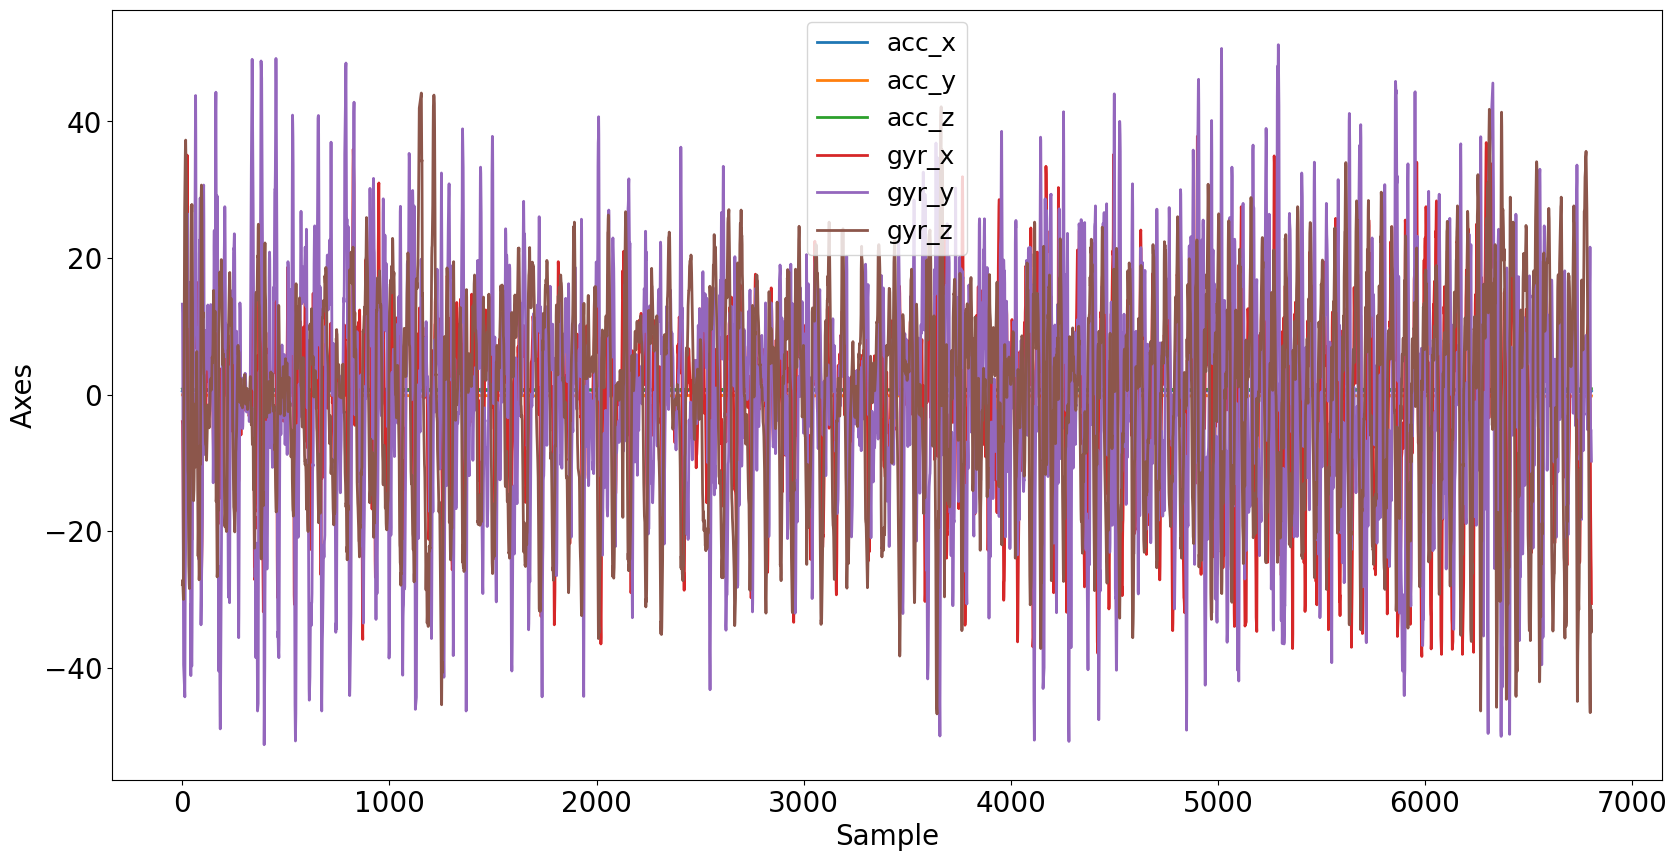

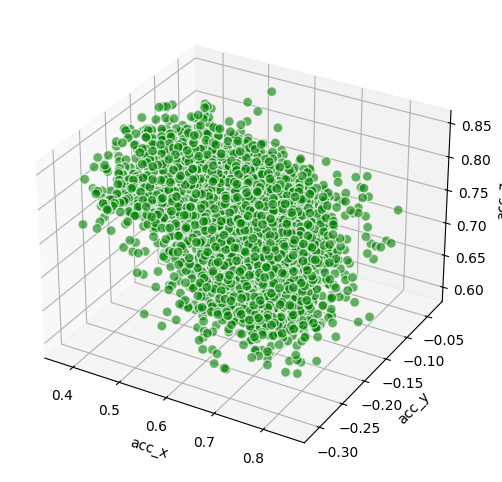

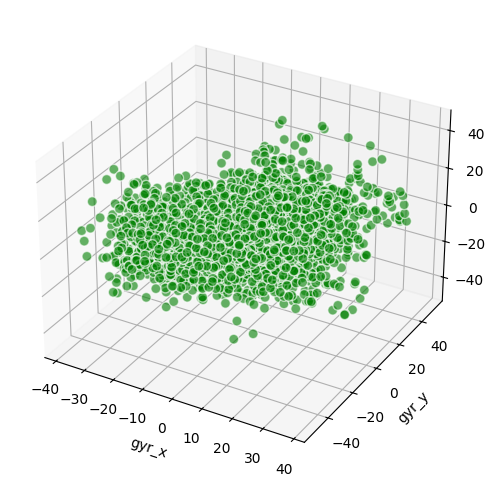

In [6]:
import numpy as np

def process_sensor_data(df, trim_size=100, z_threshold=3):
    df_trimmed = df.iloc[:-trim_size].copy()
    
    for col_name in df_trimmed.columns:
        mean_val = df_trimmed[col_name].mean()
        std_val = df_trimmed[col_name].std()
        
        z_scores = (df_trimmed[col_name] - mean_val) / std_val
        
        df_trimmed.loc[np.abs(z_scores) > z_threshold, col_name] = np.nan
        
        df_trimmed[col_name] = df_trimmed[col_name].interpolate(method='linear')
        
        df_trimmed[col_name] = df_trimmed[col_name].ffill().bfill()
        
    return df_trimmed

df_clean = process_sensor_data(df)

plot_instance_time_domain(df_clean)
plot_instance_3d(df_clean[["acc_x", "acc_y", "acc_z"]])
plot_instance_3d(df_clean[["gyr_x", "gyr_y", "gyr_z"]], axes_list=("gyr_x", "gyr_y", "gyr_z"))

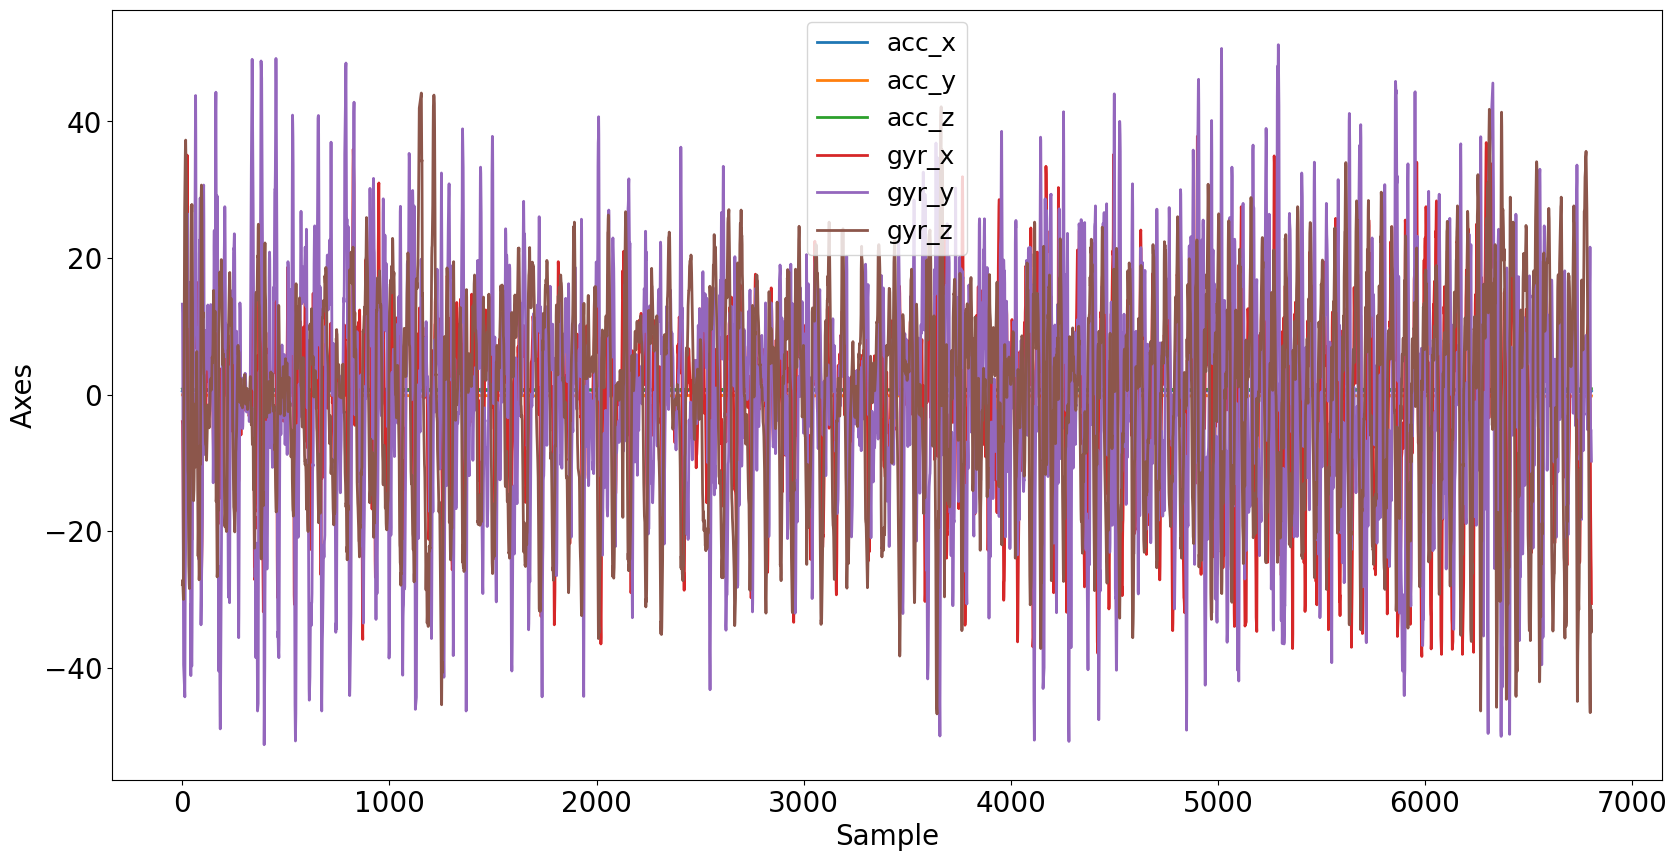

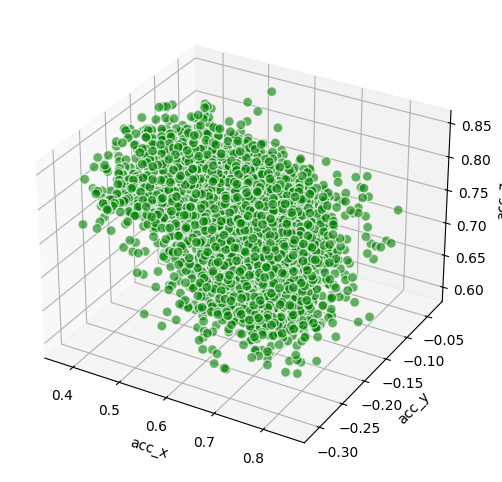

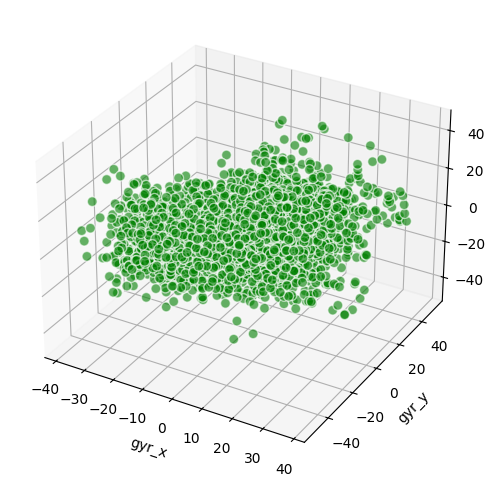

In [7]:
plot_instance_time_domain(df_clean)
plot_instance_3d(df_clean[["acc_x", "acc_y", "acc_z"]])
plot_instance_3d(df_clean[["gyr_x", "gyr_y", "gyr_z"]], axes_list=("gyr_x", "gyr_y", "gyr_z"))

Εφαρμόζουμε το Butterworth low-pass φίλτρο για να αφαιρέσουμε υψίσυχνο θόρυβο. Τυπώνουμε το σήμα πριν και μετά το φίλτρο για οπτική σύγκριση.

before filtro(Cleaned):
ButterrWorth(Filtered):


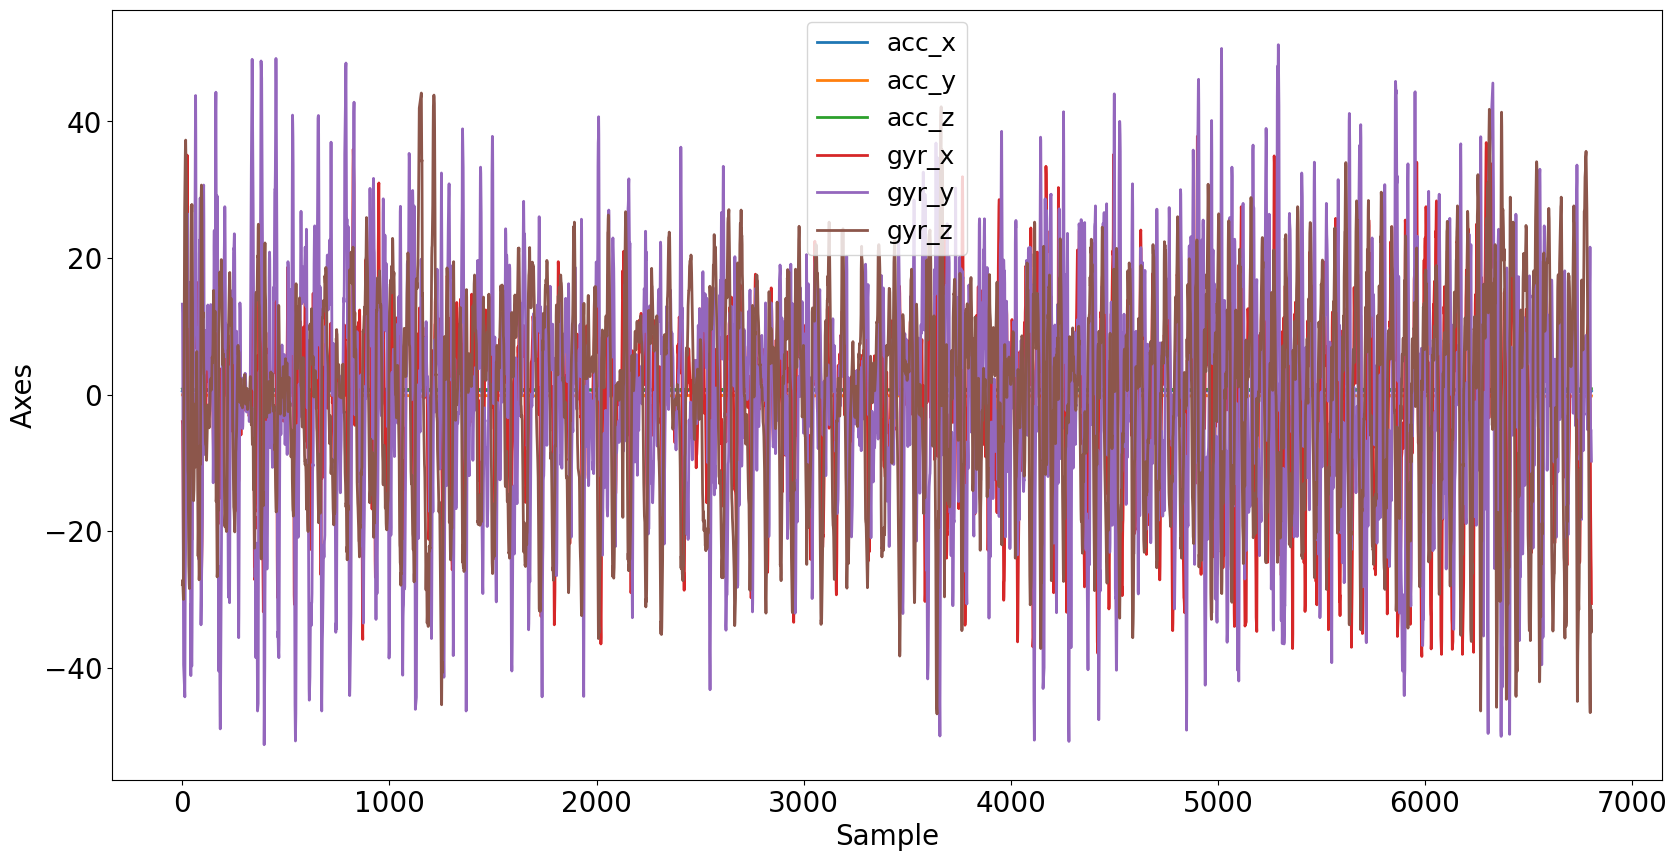

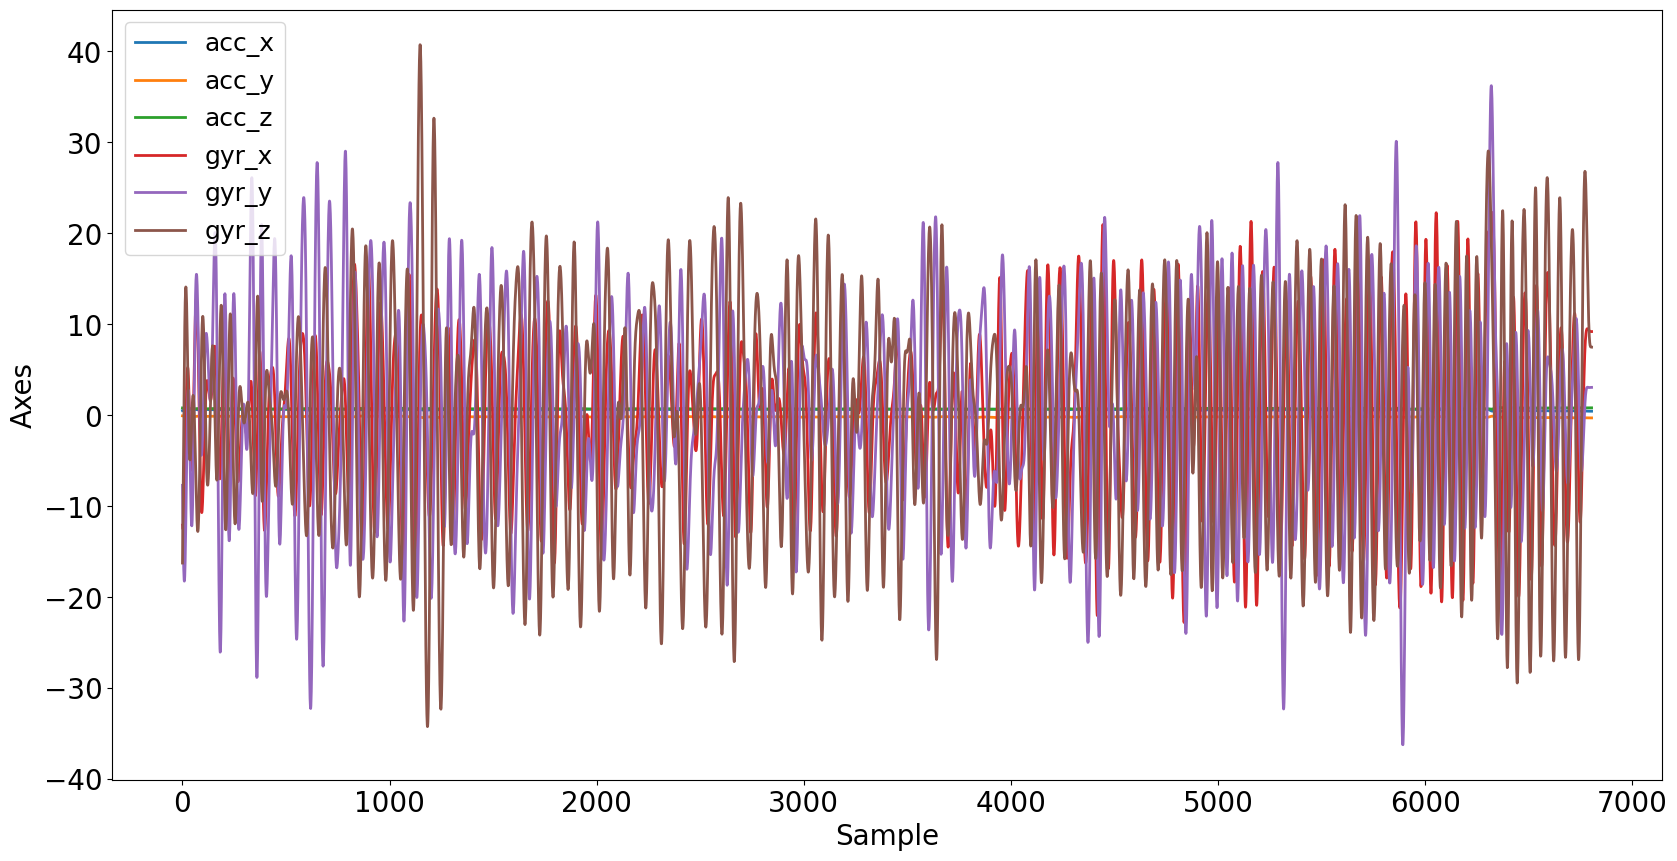

In [8]:
from utils import apply_filter

order = config["filter"]["order"]
wn = config["filter"]["wn"]

#df_small = df_clean.iloc[0:1000]

df_filtered = df_clean.apply(apply_filter, args=(order, wn, "lowpass"))
print("before filtro(Cleaned):")
plot_instance_time_domain(df_clean)

print("ButterrWorth(Filtered):")
plot_instance_time_domain(df_filtered)

Εφαρμόζουμε τον αλγόριθμο sliding window(πειράζοντας κάθε τα Parametres απο το config.yml).

In [ ]:
from utils import sliding_window_pd

window_size = config["sliding_window"]["ws"]
overlap = config["sliding_window"]["overlap"]

p_stats = config["sliding_window"]["print_stats"]

windows_list = sliding_window_pd(df_filtered, ws=window_size, overlap=overlap, print_stats=p_stats)

Επιλέγουμε τυχαία ένα παράθυρο και το οπτικοποιούμε για να βεβαιωθούμε ότι ο segmentation δουλεύει σωστά.

In [ ]:
from utils_visual import plot_instance_time_domain
import random

random_window = random.choice(windows_list)

print("Οπτικός έλεγχος ενός τυχαίου παραθύρου:")
plot_instance_time_domain(random_window)

Επεκτείνουμε τη διαδικασία σε **όλα** τα έγγραφα της βάσης: για κάθε εγγραφή κάνουμε clean → filter → sliding window → flatten, και συγκεντρώνουμε όλα τα παράθυρα σε έναν global πίνακα.

In [9]:
import pandas as pd
import numpy as np
from utils import apply_filter, sliding_window_pd, flatten_instances_df

def process_sensor_data(df, trim_size=100, z_threshold=3):
    df_trimmed = df.iloc[:-trim_size].copy()
    
    for col_name in df_trimmed.columns:
        mean_val = df_trimmed[col_name].mean()
        std_val = df_trimmed[col_name].std()
        
        z_scores = (df_trimmed[col_name] - mean_val) / std_val
        
        df_trimmed.loc[np.abs(z_scores) > z_threshold, col_name] = np.nan
        df_trimmed[col_name] = df_trimmed[col_name].interpolate(method='linear')
        df_trimmed[col_name] = df_trimmed[col_name].ffill().bfill()
        
    return df_trimmed

X_global_list = []
y_labels_list = []
user_ids_list = []

order = config["filter"]["order"]
wn = config["filter"]["wn"]
window_size = config["sliding_window"]["ws"]
overlap = config["sliding_window"]["overlap"]

all_documents = coll.find({})

for doc in all_documents:
    gesture = doc.get("gesture_id")
    user = doc.get("user")
    
    df = pd.DataFrame(doc["data"])
    
    df_clean = process_sensor_data(df)
    
    df_filtered = df_clean.apply(apply_filter, args=(order, wn, "lowpass"))
    
    windows = sliding_window_pd(
        df_filtered, 
        ws=window_size, 
        overlap=overlap, 
        print_stats=False
    )
    
    if len(windows) > 0:
        flattened_df = flatten_instances_df(windows)
        
        X_global_list.append(flattened_df.to_numpy())
        y_labels_list.extend([gesture] * len(windows))
        user_ids_list.extend([user] * len(windows))

if len(X_global_list) > 0:
    X_global = np.vstack(X_global_list)
    y_labels = np.array(y_labels_list)
    user_ids = np.array(user_ids_list)
else:
    X_global = np.array([])
    y_labels = np.array([])
    user_ids = np.array([])

print("X_global shape:", X_global.shape)
print("y_labels shape:", y_labels.shape)
print("user_ids shape:", user_ids.shape)

X_global shape: (5197, 768)
y_labels shape: (5197,)
user_ids shape: (5197,)


## Train/Test split

**Πρώτη δοκιμή split:** Χρησιμοποιούμε απλό random train/test split 80/20. Αυτή η προσέγγιση έχει πρόβλημα data leakage λόγω overlap των παραθύρων — την αντικαταστήσαμε αργότερα με session-based split.

Συνολική Ακρίβεια (Accuracy): 0.9519

Αναλυτική Αναφορά Ταξινόμησης:
                   precision    recall  f1-score   support

scroll-down-index       0.91      0.90      0.90       181
  scroll-up-index       0.93      0.92      0.92       224
 swipe-left-index       0.94      0.98      0.96       211
swipe-right-index       1.00      0.98      0.99       212
   texting-single       0.98      0.98      0.98       212

         accuracy                           0.95      1040
        macro avg       0.95      0.95      0.95      1040
     weighted avg       0.95      0.95      0.95      1040



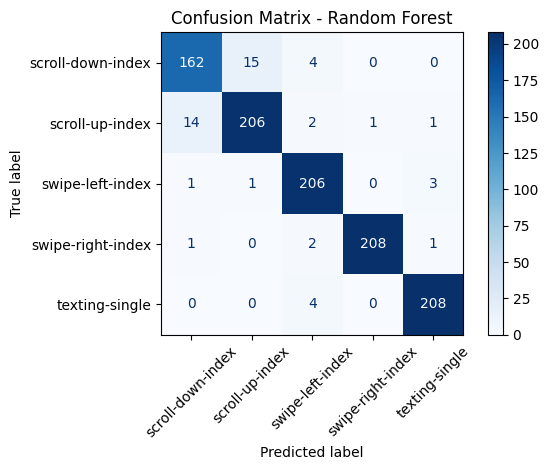

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X_global, y_labels, test_size=0.2, random_state=42, stratify=y_labels)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Συνολική Ακρίβεια (Accuracy): {accuracy:.4f}\n")

print("Αναλυτική Αναφορά Ταξινόμησης:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




**Δεύτερη δοκιμή:** User-based split — εκπαίδευση με user 01, test με user 02.Πήραμε πολυ κακό σκορ,πραγμα λογικό καθώς τα δείγματα είναι πολυ λίγα και οι κινήσεις απο άνθρωπο σε άνθρωπο διαφέρουν.

Συνολική Ακρίβεια (Accuracy): 0.0715

Αναλυτική Αναφορά Ταξινόμησης:
                   precision    recall  f1-score   support

scroll-down-index       0.00      0.00      0.00       495
  scroll-up-index       0.00      0.00      0.00       578
 swipe-left-index       0.09      0.10      0.09       526
swipe-right-index       0.00      0.00      0.00       537
   texting-single       0.11      0.28      0.16       495

         accuracy                           0.07      2631
        macro avg       0.04      0.07      0.05      2631
     weighted avg       0.04      0.07      0.05      2631



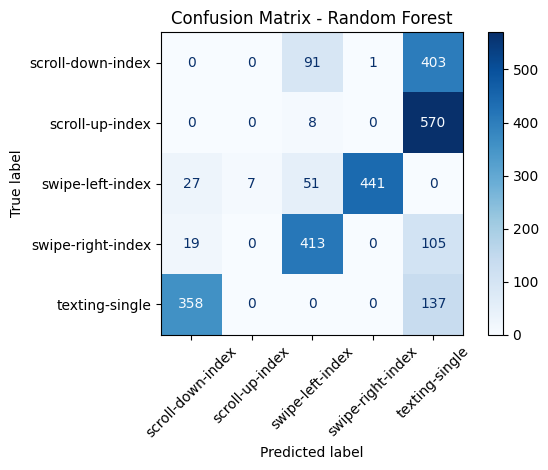

In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

train_mask = user_ids == "01"
test_mask = user_ids == "02"

X_train_raw = X_global[train_mask]
y_train_raw = y_labels[train_mask]

X_test_raw = X_global[test_mask]
y_test_raw = y_labels[test_mask]

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Συνολική Ακρίβεια (Accuracy): {accuracy:.4f}\n")

print("Αναλυτική Αναφορά Ταξινόμησης:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ελέγχουμε την κατανομή των κλάσεων στο training set για να δούμε αν είναι ισορροπημένο.

In [10]:
import numpy as np

classes, counts = np.unique(y_train_raw, return_counts=True)

for cls, count in zip(classes, counts):
    print(f"Gesture: {cls} -> Πλήθος: {count}")

Gesture: scroll-down-index -> Πλήθος: 408
Gesture: scroll-up-index -> Πλήθος: 542
Gesture: swipe-left-index -> Πλήθος: 527
Gesture: swipe-right-index -> Πλήθος: 523
Gesture: texting-single -> Πλήθος: 566


## Scaling

## Classifier - Statistical Learning

### Evaluate simple classifier

Δοκιμάζουμε μια απλή μορφή feature engineering (mean, std, max, min, var ανά άξονα) με user-based split .

Συνολική Ακρίβεια (Accuracy): 0.0468

                   precision    recall  f1-score   support

scroll-down-index       0.00      0.01      0.01       495
  scroll-up-index       0.00      0.00      0.00       578
 swipe-left-index       0.77      0.07      0.13       526
swipe-right-index       0.00      0.00      0.00       537
   texting-single       0.07      0.16      0.09       495

         accuracy                           0.05      2631
        macro avg       0.17      0.05      0.05      2631
     weighted avg       0.17      0.05      0.04      2631



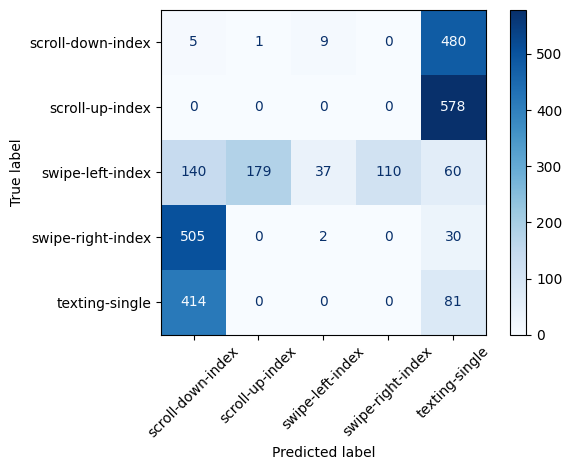

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from utils import apply_filter, sliding_window_pd

#extract features

def process_sensor_data(df, trim_size=100, z_threshold=3):
    df_trimmed = df.iloc[:-trim_size].copy()
    for col_name in df_trimmed.columns:
        mean_val = df_trimmed[col_name].mean()
        std_val = df_trimmed[col_name].std()
        z_scores = (df_trimmed[col_name] - mean_val) / std_val
        df_trimmed.loc[np.abs(z_scores) > z_threshold, col_name] = np.nan
        df_trimmed[col_name] = df_trimmed[col_name].interpolate(method='linear')
        df_trimmed[col_name] = df_trimmed[col_name].ffill().bfill()
    return df_trimmed

def extract_features(window_df):
    features = []
    for col in window_df.columns:
        features.append(window_df[col].mean())
        features.append(window_df[col].std())
        features.append(window_df[col].max())
        features.append(window_df[col].min())
        features.append(window_df[col].var())
    return features

X_global_list = []
y_labels_list = []
user_ids_list = []

order = config["filter"]["order"]
wn = config["filter"]["wn"]
window_size = config["sliding_window"]["ws"]
overlap = config["sliding_window"]["overlap"]

all_documents = coll.find({})

for doc in all_documents:
    gesture = doc.get("gesture_id")
    user = doc.get("user")
    df = pd.DataFrame(doc["data"])
    
    df_clean = process_sensor_data(df)
    df_filtered = df_clean.apply(apply_filter, args=(order, wn, "lowpass"))
    
    windows = sliding_window_pd(df_filtered, ws=window_size, overlap=overlap, print_stats=False)
    
    for window in windows:
       
        window_features = extract_features(window)
        
        X_global_list.append(window_features)
        y_labels_list.append(gesture)
        user_ids_list.append(user)

X_global = np.array(X_global_list)
y_labels = np.array(y_labels_list)
user_ids = np.array(user_ids_list)

train_mask = user_ids == "01"
test_mask = user_ids == "02"

X_train_raw = X_global[train_mask]
y_train_raw = y_labels[train_mask]
X_test_raw = X_global[test_mask]
y_test_raw = y_labels[test_mask]

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(f"Συνολική Ακρίβεια (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, cmap='Blues')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Για να πετύχουμε καθολική αναγνώριση, θα χρειαζόμασταν ένα dataset με 40-50+ χρήστες.
Λόγω αυτού του περιορισμού των δεδομένων, επιλέξαμε στρατηγικά το **Session-Based Split**.Αυτό μας επέτρεψε να αξιολογήσουμε τη στιβαρότητα του Feature Engineering pipeline μας σε μελλοντικά, «αόρατα» δεδομένα (Session 5), διασφαλίζοντας ότι δεν υπάρχει Data Leakage

Συνολική Ακρίβεια (Accuracy) [Session-Based Split]: 0.7743

                   precision    recall  f1-score   support

scroll-down-index       0.63      0.48      0.54       195
  scroll-up-index       0.64      0.54      0.59       196
 swipe-left-index       0.98      0.90      0.94       196
swipe-right-index       0.81      0.99      0.89       226
   texting-single       0.76      0.93      0.84       184

         accuracy                           0.77       997
        macro avg       0.76      0.77      0.76       997
     weighted avg       0.77      0.77      0.76       997



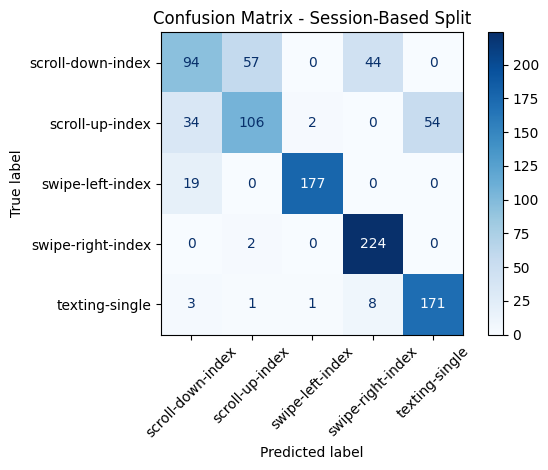

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from utils import apply_filter, sliding_window_pd

#allos tropos gia na min exei data leakage(feature engineering me sliding window kai session-based split)

def process_sensor_data(df, trim_size=100, z_threshold=3):
    df_trimmed = df.iloc[:-trim_size].copy()
    for col_name in df_trimmed.columns:
        mean_val = df_trimmed[col_name].mean()
        std_val = df_trimmed[col_name].std()
        z_scores = (df_trimmed[col_name] - mean_val) / std_val
        df_trimmed.loc[np.abs(z_scores) > z_threshold, col_name] = np.nan
        df_trimmed[col_name] = df_trimmed[col_name].interpolate(method='linear')
        df_trimmed[col_name] = df_trimmed[col_name].ffill().bfill()
    return df_trimmed

def extract_features(window_df):
    features = []
    for col in window_df.columns:
        features.extend([
            window_df[col].mean(),
            window_df[col].std(),
            window_df[col].max(),
            window_df[col].min(),
            window_df[col].var()
        ])
    return features


X_train_list, y_train_list = [], []
X_test_list,  y_test_list  = [], []


session_tracker = {} 

order = config["filter"]["order"]
wn = config["filter"]["wn"]
window_size = config["sliding_window"]["ws"]
overlap = config["sliding_window"]["overlap"]

all_documents = coll.find({})

for doc in all_documents:
    gesture = doc.get("gesture_id")
    user = doc.get("user")
    
    
    key = f"{user}_{gesture}"
    
   
    session_tracker[key] = session_tracker.get(key, 0) + 1
    current_session = session_tracker[key]
    
    df = pd.DataFrame(doc["data"])
    df_clean = process_sensor_data(df)
    df_filtered = df_clean.apply(apply_filter, args=(order, wn, "lowpass"))
    
    windows = sliding_window_pd(df_filtered, ws=window_size, overlap=overlap, print_stats=False)
    
    for window in windows:
        window_features = extract_features(window)
        
        
        if current_session == 5:
            X_test_list.append(window_features)
            y_test_list.append(gesture)
        
        else:
            X_train_list.append(window_features)
            y_train_list.append(gesture)

X_train_raw = np.array(X_train_list)
y_train_raw = np.array(y_train_list)
X_test_raw = np.array(X_test_list)
y_test_raw = np.array(y_test_list)


le = LabelEncoder()

le.fit(np.concatenate((y_train_raw, y_test_raw)))

y_train = le.transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(f"Συνολική Ακρίβεια (Accuracy) [Session-Based Split]: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, cmap='Blues')
plt.title("Confusion Matrix - Session-Based Split")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Apply optimization with Grid Search and/or Cross-validation

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier